In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import os
import sys
from sklearn.preprocessing import MaxAbsScaler
# append source to sys path
src_path = '../src' 
if src_path not in sys.path:
    sys.path.append(src_path)

import dataprocessing as dp

## Read data

In [3]:
data_A = dp.read_data('A')
data_B = dp.read_data('B')
data_C = dp.read_data('C')

data_A.head()

,absolute_humidity_2m:gm3,air_density_2m:kgm3,ceiling_height_agl:m,clear_sky_energy_1h:J,clear_sky_rad:W,cloud_base_agl:m,dew_or_rime:idx,dew_point_2m:K,diffuse_rad:W,diffuse_rad_1h:J,direct_rad:W,direct_rad_1h:J,effective_cloud_cover:p,elevation:m,fresh_snow_12h:cm,fresh_snow_1h:cm,fresh_snow_24h:cm,fresh_snow_3h:cm,fresh_snow_6h:cm,is_day:idx,is_in_shadow:idx,msl_pressure:hPa,precip_5min:mm,precip_type_5min:idx,pressure_100m:hPa,pressure_50m:hPa,prob_rime:p,rain_water:kgm2,relative_humidity_1000hPa:p,sfc_pressure:hPa,snow_density:kgm3,snow_depth:cm,snow_drift:idx,snow_melt_10min:mm,snow_water:kgm2,sun_azimuth:d,sun_elevation:d,super_cooled_liquid_water:kgm2,t_1000hPa:K,total_cloud_cover:p,visibility:m,wind_speed_10m:ms,wind_speed_u_10m:ms,wind_speed_v_10m:ms,wind_speed_w_1000hPa:ms,pv_measurement
2019-06-02 22:00:00,7.7,1.230,1744.900024,0.0,0.0,1744.900024,0.0,280.299988,0.0,0.0,0.0,0.0,98.699997,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1006.799988,0.0,0.0,994.200012,1000.299988,0.0,0.0,73.099998,1006.299988,NaN,0.0,0.0,-0.0,0.1,342.834015,-3.202,0.0,285.899994,100.0,39640.101562,3.7,-3.6,-0.8,-0.0,0.0
2019-06-02 22:15:00,7.7,1.229,1734.000000,0.0,0.0,1734.000000,0.0,280.299988,0.0,0.0,0.0,0.0,99.000000,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1006.500000,0.0,0.0,993.900024,999.900024,0.0,0.0,72.199997,1006.000000,NaN,0.0,0.0,-0.0,0.2,346.294006,-3.650,0.0,286.100006,100.0,40123.898438,3.6,-3.6,-0.6,-0.0,NaN
2019-06-02 22:30:00,7.7,1.228,1723.500000,0.0,0.0,1723.500000,0.0,280.299988,0.0,0.0,0.0,0.0,99.199997,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1006.099976,0.0,0.0,993.599976,999.599976,0.0,0.0,71.199997,1005.599976,NaN,0.0,0.0,-0.0,0.2,349.768005,-3.998,0.0,286.299988,100.0,40628.300781,3.6,-3.6,-0.4,-0.0,NaN
2019-06-02 22:45:00,7.7,1.226,1713.400024,0.0,0.0,1713.400024,0.0,280.299988,0.0,0.0,0.0,0.0,99.400002,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1005.799988,0.0,0.0,993.299988,999.299988,0.0,0.0,70.199997,1005.299988,NaN,0.0,0.0,-0.0,0.2,353.251007,-4.247,0.0,286.600006,100.0,41153.601562,3.5,-3.5,-0.2,-0.0,NaN
2019-06-02 23:00:00,7.7,1.225,1703.599976,0.0,0.0,1703.599976,0.0,280.299988,0.0,0.0,0.0,0.0,99.599998,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1005.500000,0.0,0.0,993.000000,999.000000,0.0,0.0,69.199997,1005.000000,NaN,0.0,0.0,-0.0,0.2,356.742004,-4.393,0.0,286.799988,100.0,41699.898438,3.5,-3.5,0.0,-0.0,0.0


In [4]:
def get_correlation_matrix(data: pd.DataFrame, method: str = 'kendall') -> pd.DataFrame:
    """
    Calculate the correlation matrix of the given DataFrame using the specified method.

    Parameters:
    data (pd.DataFrame): The input DataFrame.
    method (str): The correlation method to use ('pearson', 'kendall', 'spearman').

    Returns:
    pd.DataFrame: The correlation matrix.
    """
    correlation_matrix = data.corr(method=method)
    correlation_matrix.dropna(thresh=2, inplace=True)
    correlation_matrix.dropna(axis=1, thresh=2, inplace=True)
    return correlation_matrix

data_corr_A = get_correlation_matrix(data_A, method='kendall')
# data_corr_B = get_correlation_matrix(data_B, method='kendall')
# data_corr_C = get_correlation_matrix(data_C, method='kendall')

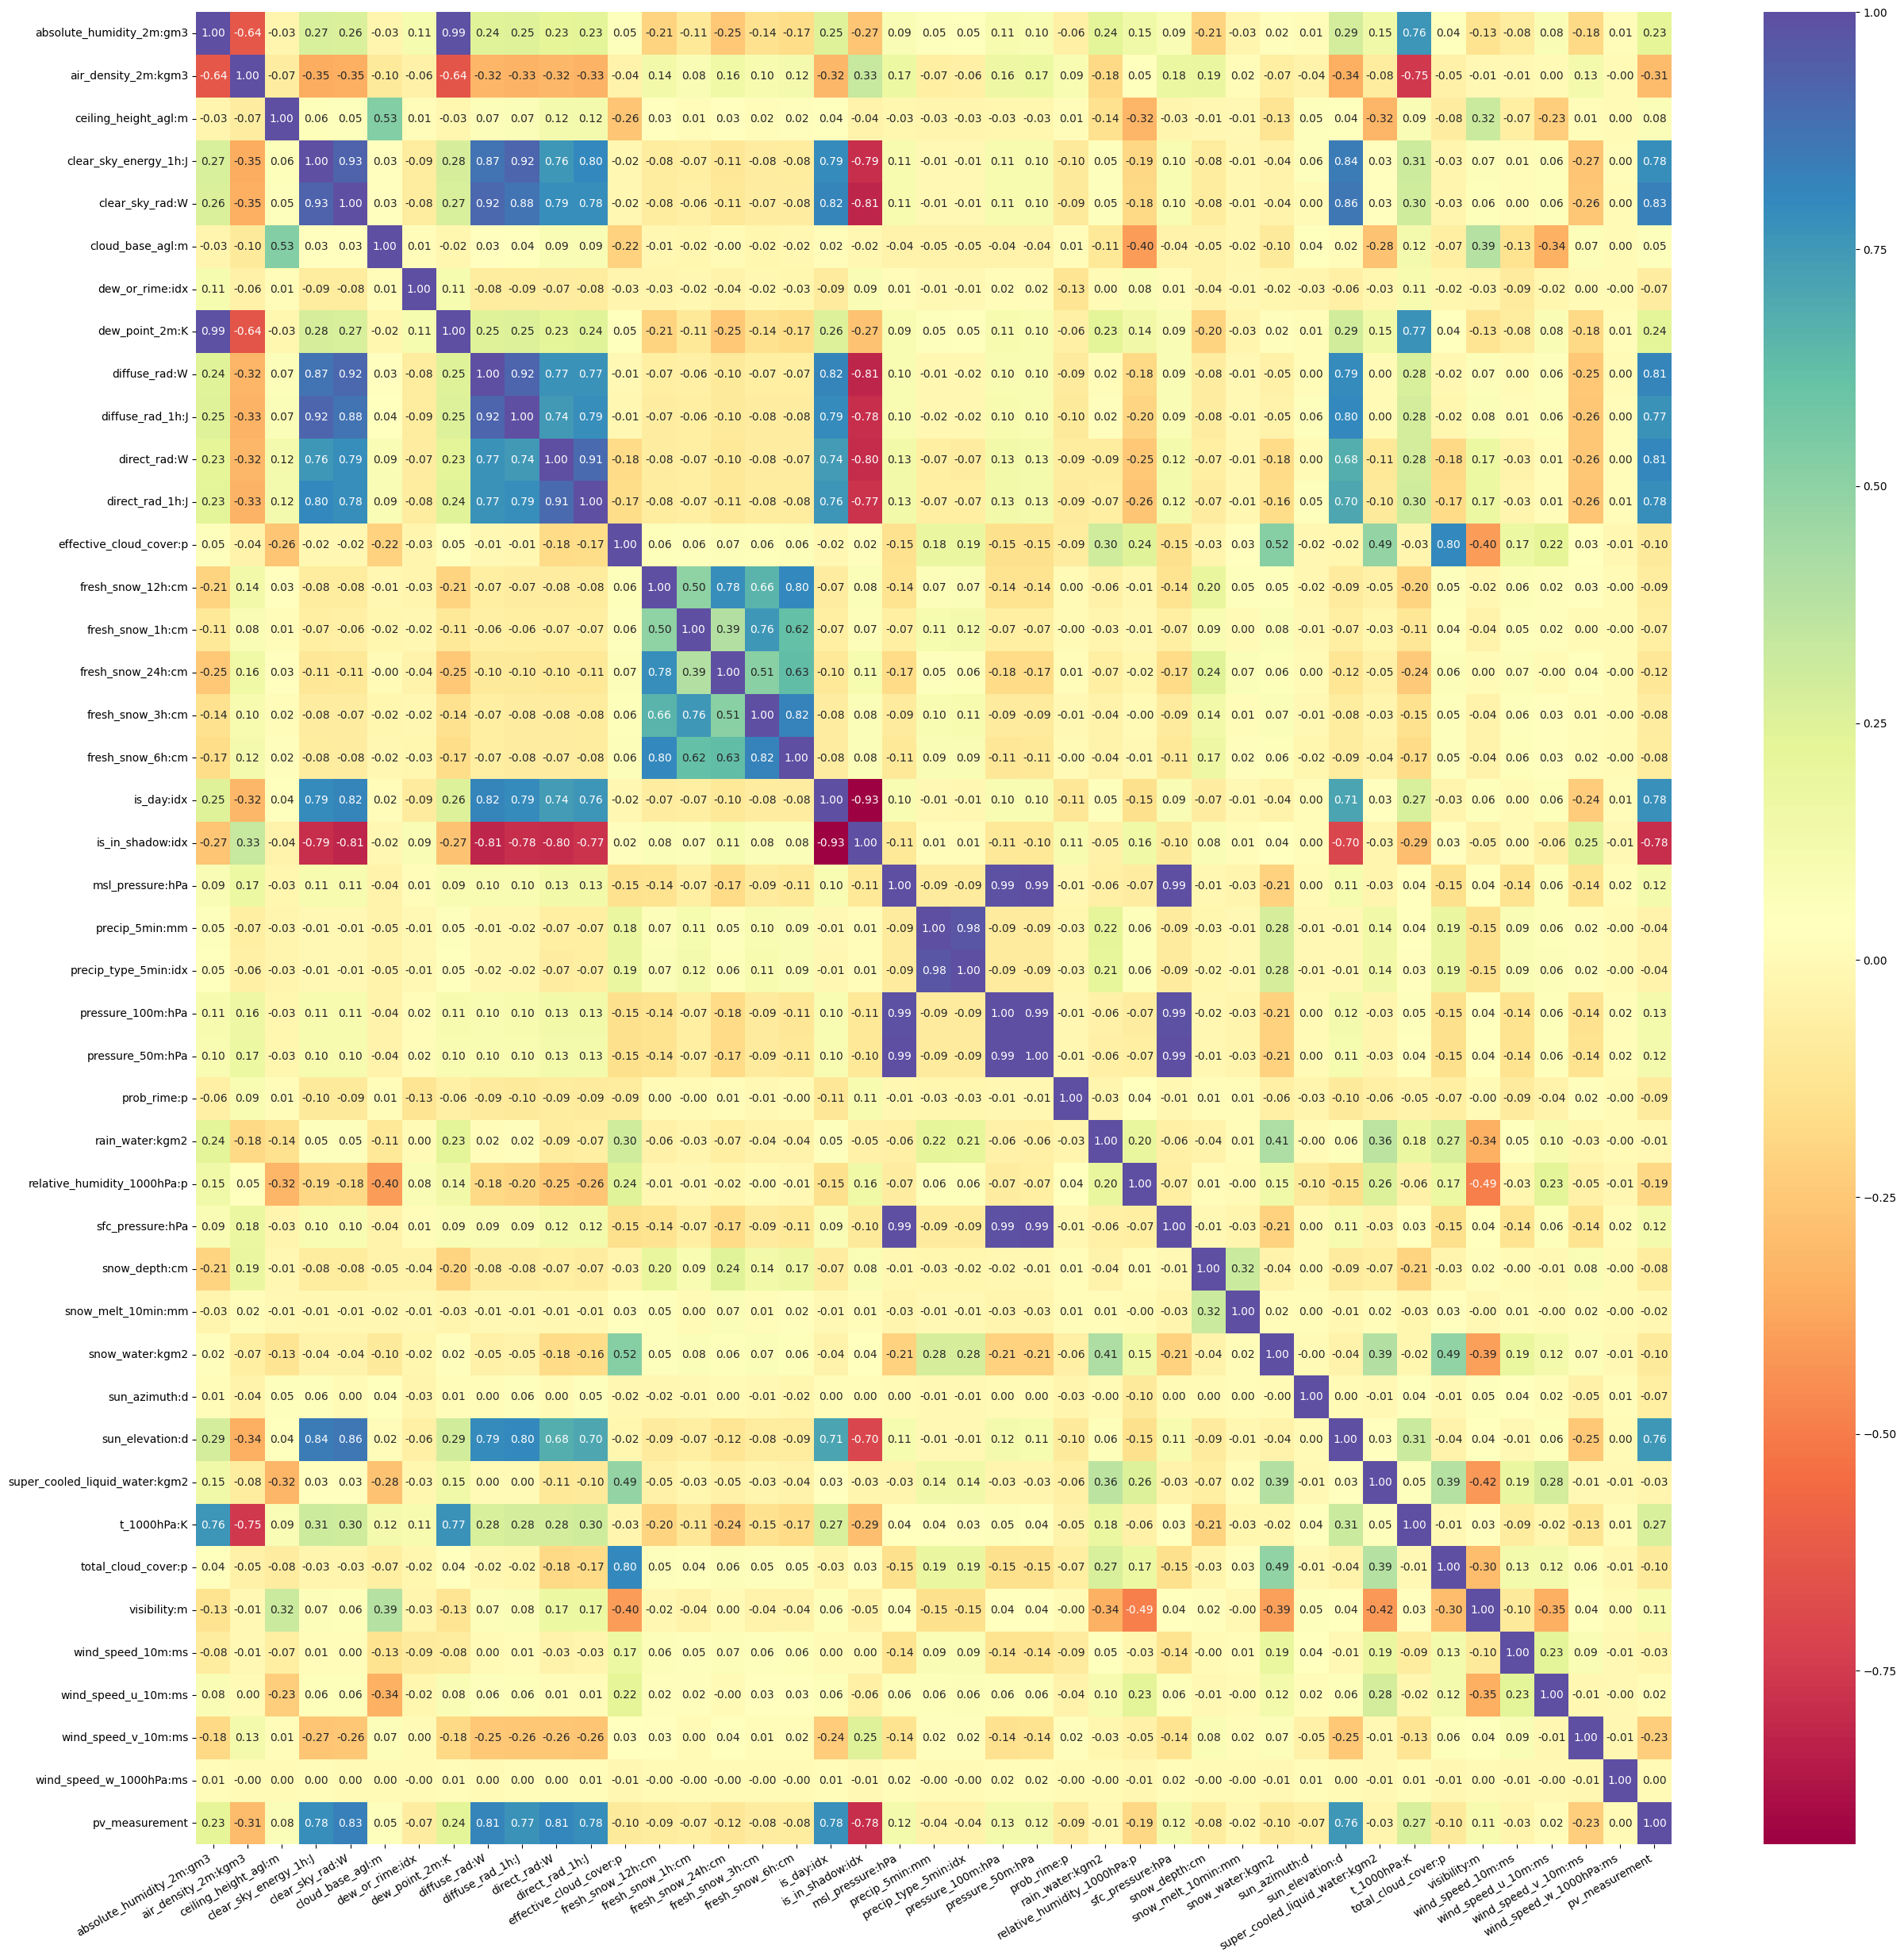

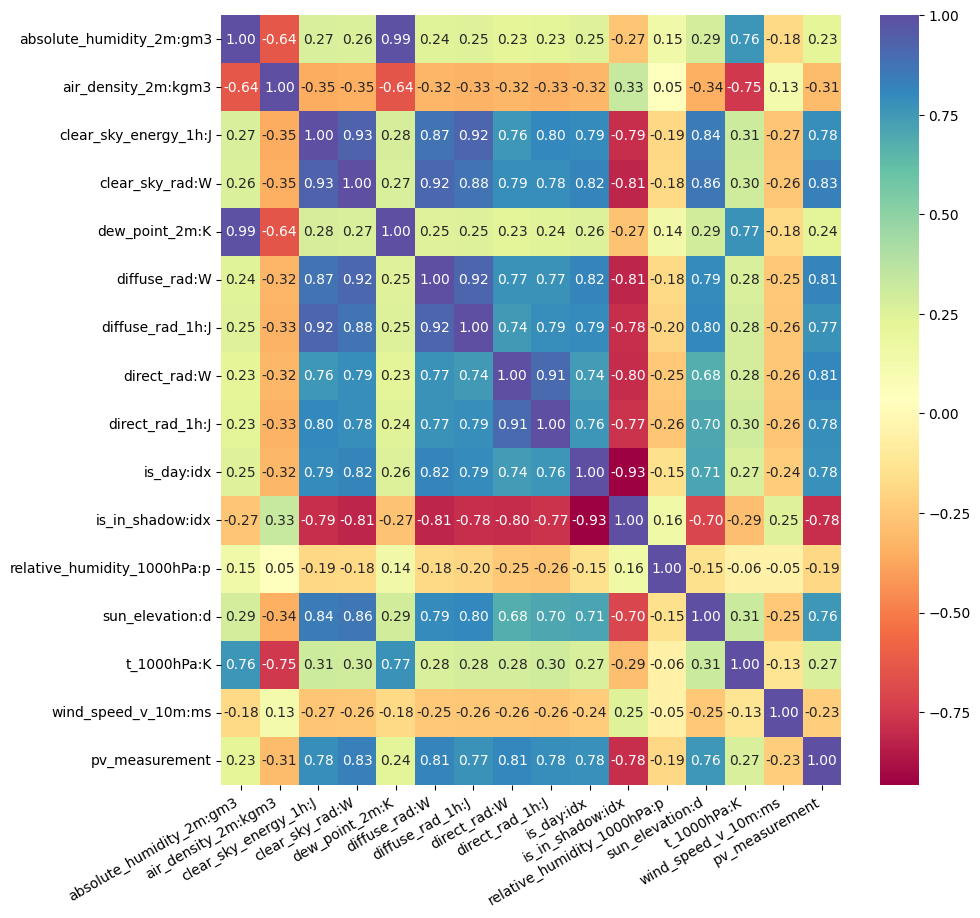

In [ ]:

plt.figure(figsize=(30, 30))
sns.heatmap(data_corr_A, annot=True, fmt=".2f", cmap="Spectral")
plt.xticks(rotation=30, ha='right')
plt.show() #supress text output from seaborn


# keys = data_corr_A.drop(columns=["pv_measurement"]).keys()

most_corr_A = dp.filter_correlation_matrix(data_corr_A, threshold=0.15)
plt.figure(figsize=(10, 10))
sns.heatmap(most_corr_A, annot=True, fmt=".2f", cmap="Spectral")
plt.xticks(rotation=30, ha='right')
plt.show() #supress text output from seaborn





### notes to self
* Kendall Tau is best for this kind of data, however, find redundancy with pearson >.95

## plot general overview (resampled daily mean og big subset)

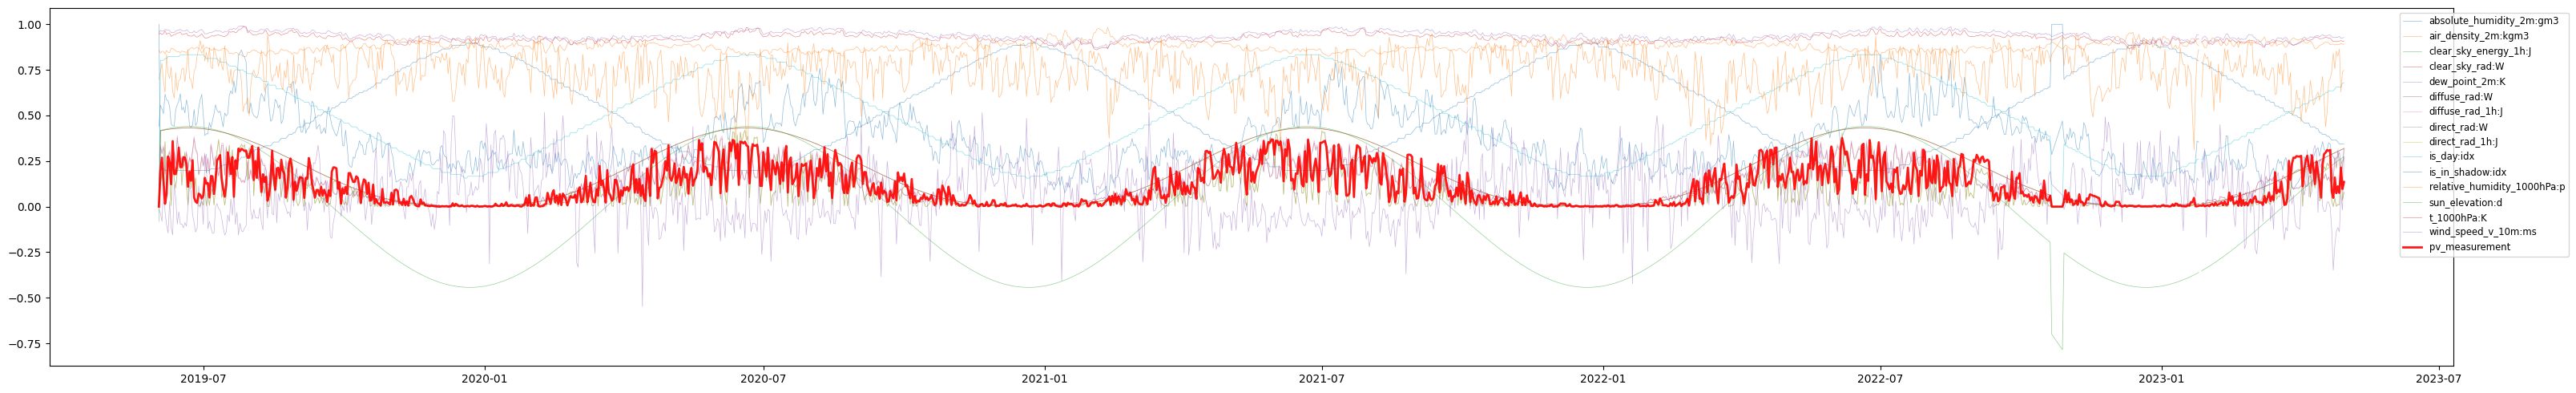

In [28]:
scaler = MaxAbsScaler()
data_A_scaled = pd.DataFrame(scaler.fit_transform(data_A), columns=data_A.columns, index=data_A.index)
data_A_corr_scaled = data_A_scaled[most_corr_A.columns].resample('D').mean()
data_A_corr_scaled.dropna(subset=['pv_measurement'], inplace=True)

plt.figure(figsize=(32, 5))

for col in data_A_corr_scaled.columns:
    if col != 'pv_measurement':
        plt.plot(data_A_corr_scaled.index, data_A_corr_scaled[col], alpha=0.5, linewidth=0.5, label=col)
plt.plot( data_A_corr_scaled.index, data_A_corr_scaled['pv_measurement'], color='red', alpha=0.9, linewidth=2, label='pv_measurement')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize='small')
plt.tight_layout()
plt.show()


## Plot general overview of small subset (pv, direct_rad, diffuse rad and clear_sky_rad)

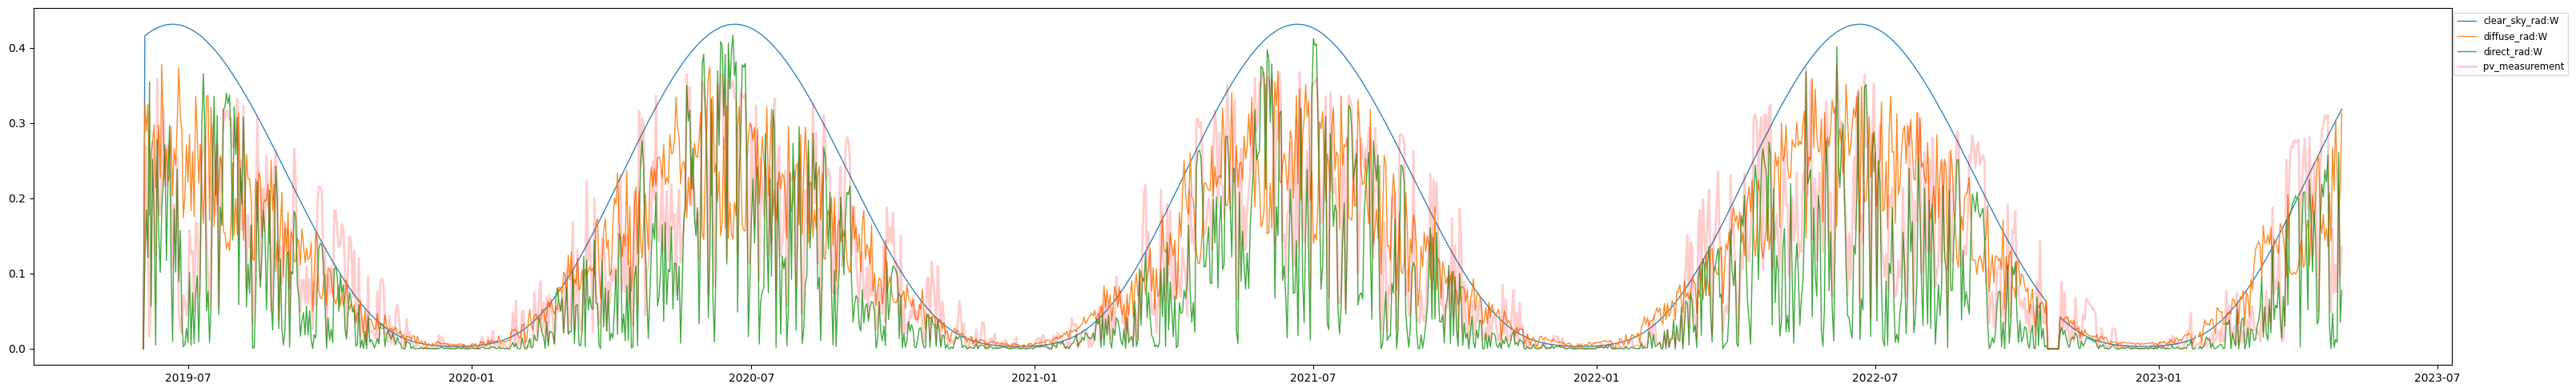

In [49]:
data_A_corr_scaled_pruned = data_A_corr_scaled[['clear_sky_rad:W', 'diffuse_rad:W', 'direct_rad:W', 'pv_measurement']]

plt.figure(figsize=(32, 5))
for col in data_A_corr_scaled_pruned.columns:
    if col != 'pv_measurement':
        plt.plot(data_A_corr_scaled_pruned.index, data_A_corr_scaled_pruned[col], alpha=0.9, linewidth=1, label=col)
plt.plot( data_A_corr_scaled_pruned.index, data_A_corr_scaled_pruned['pv_measurement'], color='red', alpha=0.2, linewidth=2, label='pv_measurement')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize='small')
plt.tight_layout()
plt.show()

### Plot a single month of small subset without resampling

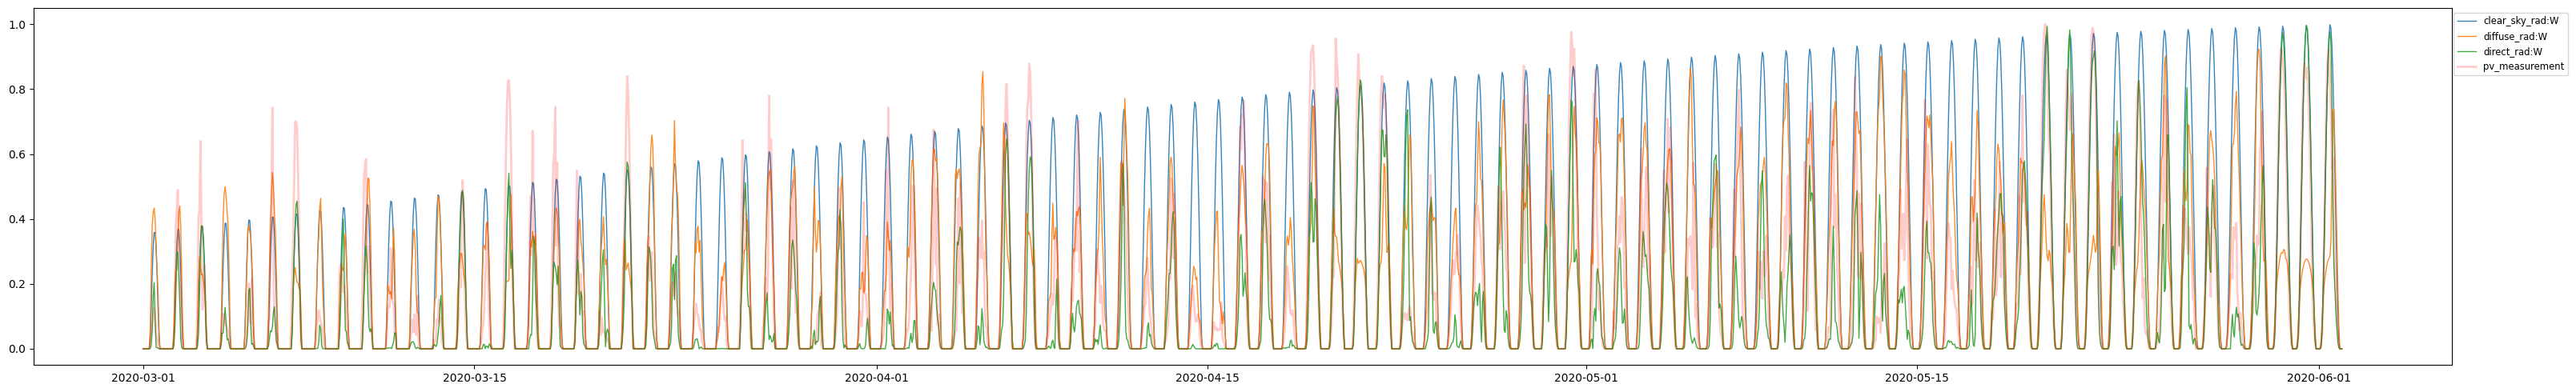

In [54]:
data_A_scaled_day = data_A[data_A_corr_scaled_pruned.columns].loc['2020-03-01':'2020-06-01']
data_A_scaled_day = pd.DataFrame(scaler.fit_transform(data_A_scaled_day), columns=data_A_scaled_day.columns, index=data_A_scaled_day.index)
data_A_scaled_day.dropna(subset=['pv_measurement'], inplace=True)

plt.figure(figsize=(32, 5))
for col in data_A_scaled_day.columns:
    if col != 'pv_measurement':
        plt.plot(data_A_scaled_day.index, data_A_scaled_day[col], alpha=0.9, linewidth=1, label=col)
plt.plot( data_A_scaled_day.index, data_A_scaled_day['pv_measurement'], color='red', alpha=0.2, linewidth=2, label='pv_measurement')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize='small')
plt.tight_layout()
plt.show()

In [58]:
# Group data by day and calculate the correlation between 'direct_rad:W' and 'pv_measurement'
daily_correlations = data_A_scaled_day.groupby(data_A_scaled_day.index.date).apply(
    lambda group: group[['direct_rad:W', 'pv_measurement']].corr(method='kendall').iloc[0, 1]
)

# Find the day with the highest correlation
most_correlated_day = daily_correlations.idxmax()
most_correlation_value = daily_correlations.max()

# Find the day with the lowest correlation
least_correlated_day = daily_correlations.idxmin()
least_correlation_value = daily_correlations.min()

# Print the results
print(f"Day with highest correlation: {most_correlated_day}, Correlation: {most_correlation_value:.2f}")
print(f"Day with lowest correlation: {least_correlated_day}, Correlation: {least_correlation_value:.2f}")

Day with highest correlation: 2020-03-12, Correlation: 0.81
Day with lowest correlation: 2020-03-11, Correlation: 0.65


Notes to self: Burde sikkert ha en feature som fanger seasonality (ref. clear sky radiation funker som et tak for pv om sommeren, men ikke våren/høsten)

Kan det funke å bruke en typ svm regressor som en feature?

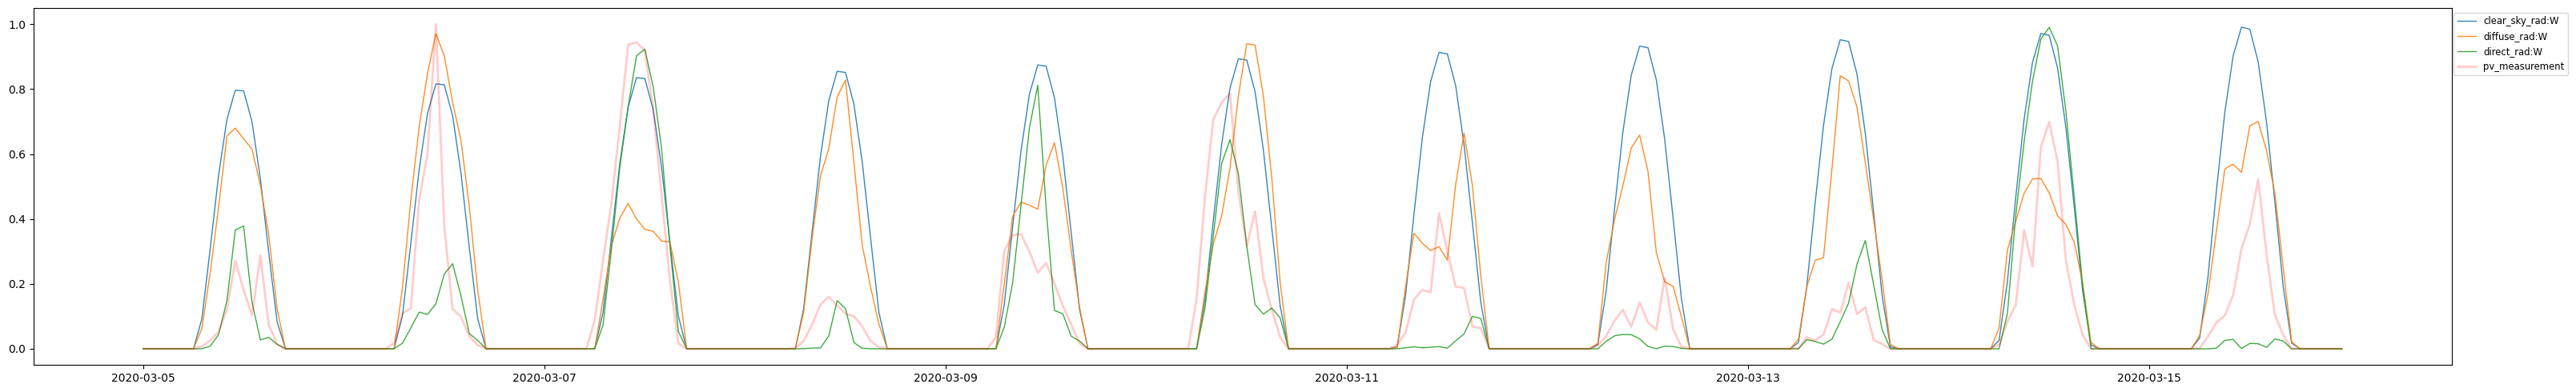

In [59]:
data_A_scaled_day = data_A[data_A_corr_scaled_pruned.columns].loc['2020-03-5':'2020-03-15']
data_A_scaled_day = pd.DataFrame(scaler.fit_transform(data_A_scaled_day), columns=data_A_scaled_day.columns, index=data_A_scaled_day.index)
data_A_scaled_day.dropna(subset=['pv_measurement'], inplace=True)

plt.figure(figsize=(32, 5))
for col in data_A_scaled_day.columns:
    if col != 'pv_measurement':
        plt.plot(data_A_scaled_day.index, data_A_scaled_day[col], alpha=0.9, linewidth=1, label=col)
plt.plot( data_A_scaled_day.index, data_A_scaled_day['pv_measurement'], color='red', alpha=0.2, linewidth=2, label='pv_measurement')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize='small')
plt.tight_layout()
plt.show()